# 📊 Instructor Effectiveness Analysis

### Analyzing Student Engagement & Learning Outcomes Using Python

**Author:** Subhash Uniyal &nbsp;|&nbsp; **Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn

---

## Introduction

The objective of this project is to analyze instructor effectiveness using various educational performance metrics such as course completion rate, quiz scores, dropout rate, watch time, assignment submission rate, forum activity, and student feedback. The analysis aims to identify patterns, evaluate instructor performance, and provide actionable recommendations for improving student engagement and learning outcomes.

## Business Problem

Educational platforms invest heavily in instructors, but without measurable performance data it is difficult to know which instructors and courses are driving strong outcomes, and which are causing students to disengage or drop out.

**This analysis answers:**
- Which factors are most strongly linked to student dropout and low completion?
- Which instructors and courses are performing best, and why?
- What concrete actions can improve completion rate, engagement, and satisfaction?

**Dataset:** 2,000 batch-level records covering completion rate, quiz scores, dropout rate, watch time, assignment submission, forum activity, and feedback across instructors and courses.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Display plots inside notebook
%matplotlib inline

In [2]:
# Load the dataset (place the dataset file inside the /data folder)
df = pd.read_excel("data/instructor_effectiveness_dataset_2000_rows.xlsx")
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [7]:
print('rows, columns:',df.shape)

rows, columns: (2000, 12)


In [8]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [9]:
# Summary statistics
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [10]:
# Display all column names
df.columns

Index(['batch_id', 'instructor_id', 'course_id', 'completion_rate',
       'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
       'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
       'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')

In [11]:
# Data type of each column
df.dtypes

batch_id                       object
instructor_id                  object
course_id                      object
completion_rate               float64
avg_score_improvement         float64
avg_quiz_score                float64
dropout_rate                  float64
avg_watch_time                float64
assignment_submission_rate    float64
forum_activity_rate           float64
avg_feedback_score            float64
feedback_response_rate        float64
dtype: object

## Data Cleaning

In [12]:
# Check missing values
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [13]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [14]:
# Check percentage columns
percentage_columns = [
    'completion_rate',
    'dropout_rate',
    'assignment_submission_rate',
    'forum_activity_rate',
    'feedback_response_rate'
]

for col in percentage_columns:
    print(f"{col}: Min = {df[col].min()}, Max = {df[col].max()}")

completion_rate: Min = 0.3, Max = 0.98
dropout_rate: Min = 0.02, Max = 0.7
assignment_submission_rate: Min = 0.251110803718633, Max = 1.0
forum_activity_rate: Min = 0.0, Max = 0.641111144104131
feedback_response_rate: Min = 0.259935242316562, Max = 1.0


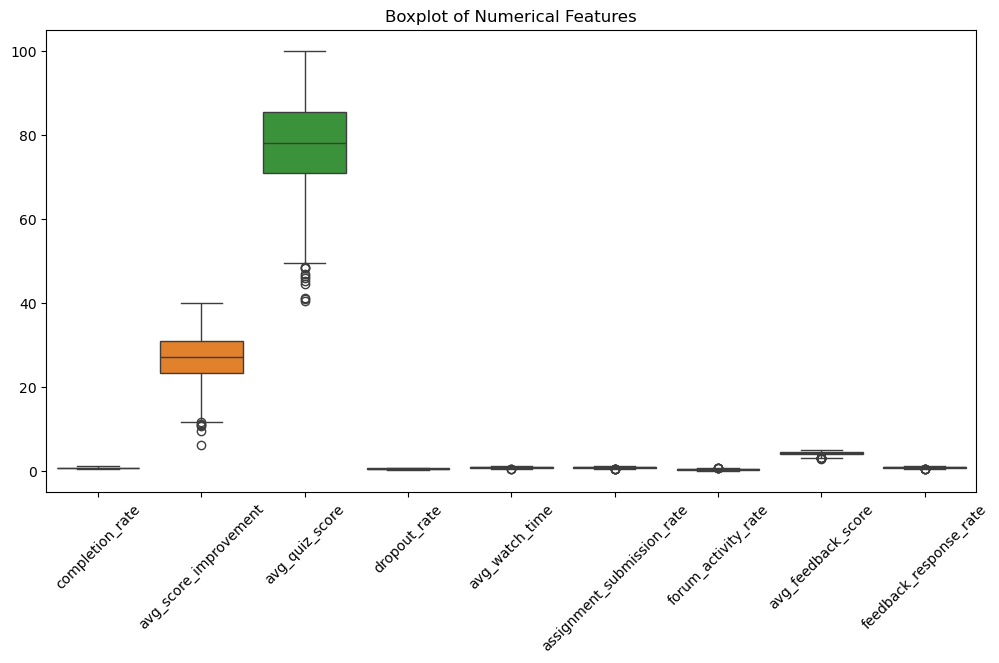

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

### Data Cleaning Summary

- Checked for missing values.
- Checked for duplicate records.
- Removed duplicate records (if any).
- Verified data types.
- Checked percentage columns for valid ranges.
- Inspected numerical columns for outliers using boxplots.

# Exploratory Data Analysis (EDA)

In [19]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.0,0.602808,0.159667,0.300000,0.489260,0.603091,0.712797,0.980000
avg_score_improvement,2000.0,27.035844,5.716641,6.159240,23.124673,26.938629,30.885600,40.000000
avg_quiz_score,2000.0,77.956126,10.695618,40.386725,70.897590,78.020567,85.444286,100.000000
dropout_rate,2000.0,0.394883,0.162747,0.020000,0.280035,0.394820,0.511432,0.700000
avg_watch_time,2000.0,0.776515,0.145231,0.287440,0.675076,0.780330,0.894242,1.000000
assignment_submission_rate,2000.0,0.753188,0.148058,0.251111,0.652110,0.756380,0.856458,1.000000
forum_activity_rate,2000.0,0.250300,0.100640,0.000000,0.179845,0.249771,0.319204,0.641111
avg_feedback_score,2000.0,4.207134,0.419209,2.639915,3.918986,4.205989,4.503437,5.000000
feedback_response_rate,2000.0,0.736519,0.149412,0.259935,0.633293,0.737213,0.845876,1.000000


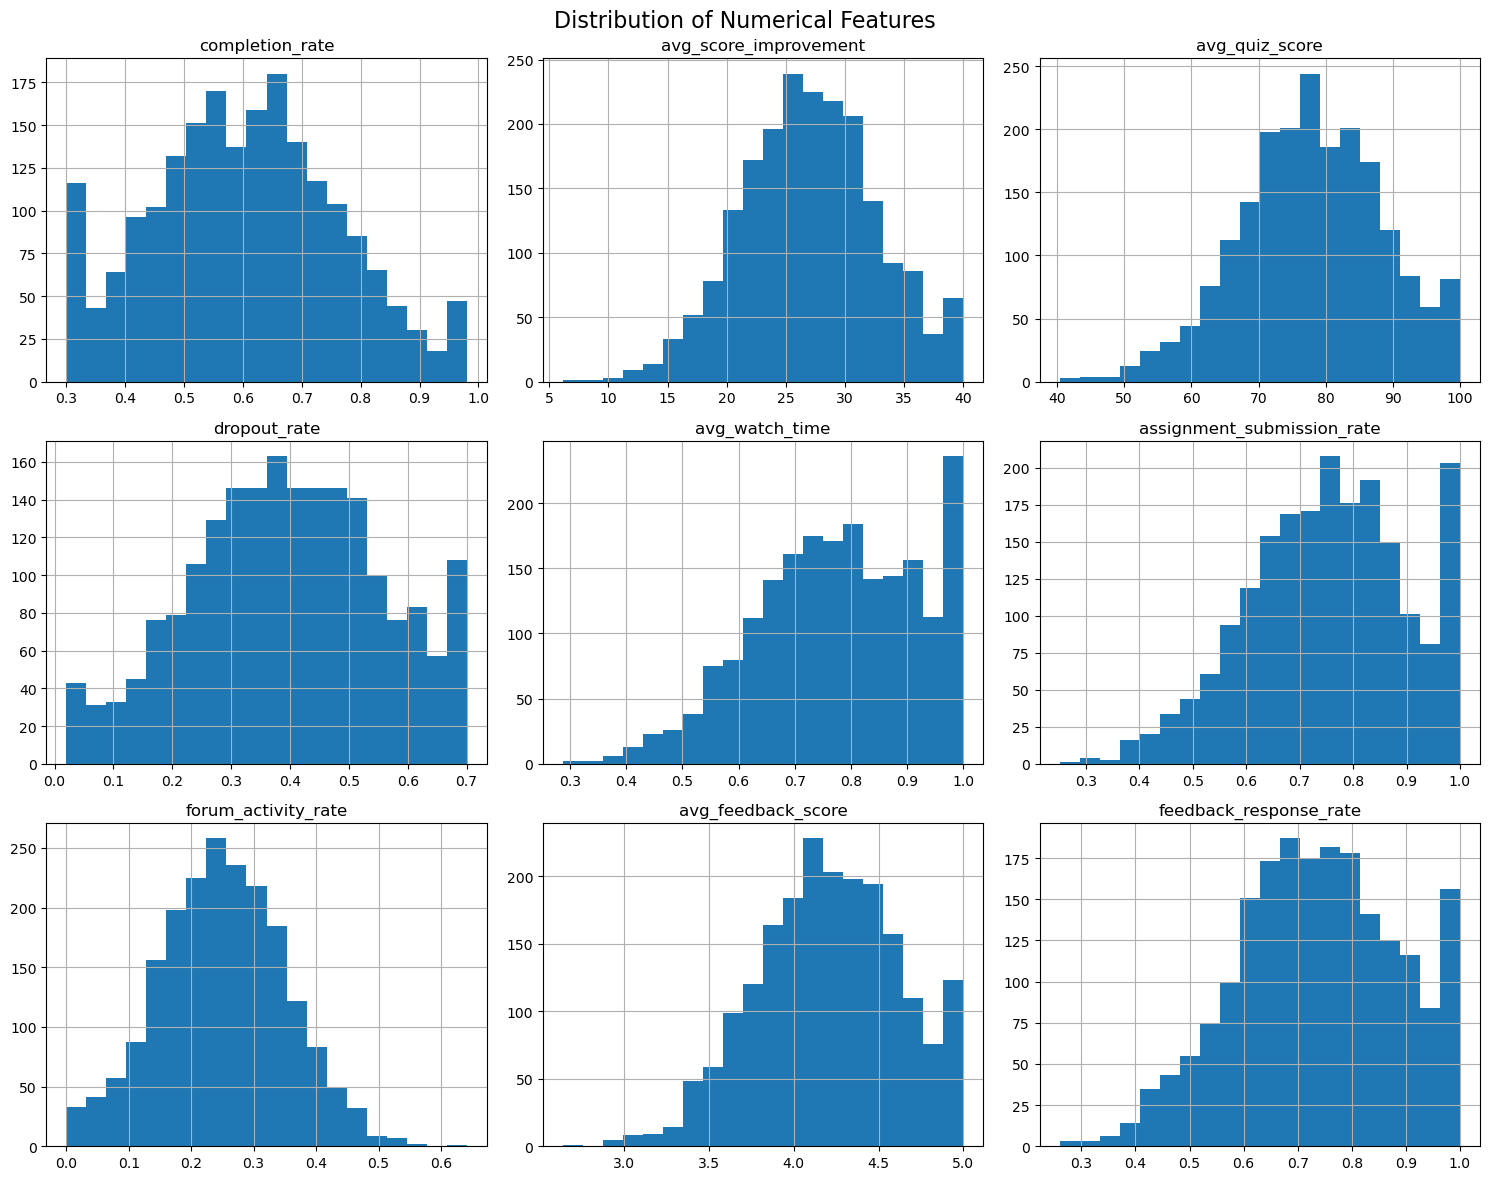

In [20]:
# Histograms of all numerical columns
df.hist(figsize=(15,12), bins=20, )
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Observation

- Most numerical variables appear to follow a reasonable distribution.
- There are no obvious abnormal patterns.
- The distributions provide insight into the spread of instructor performance metrics.

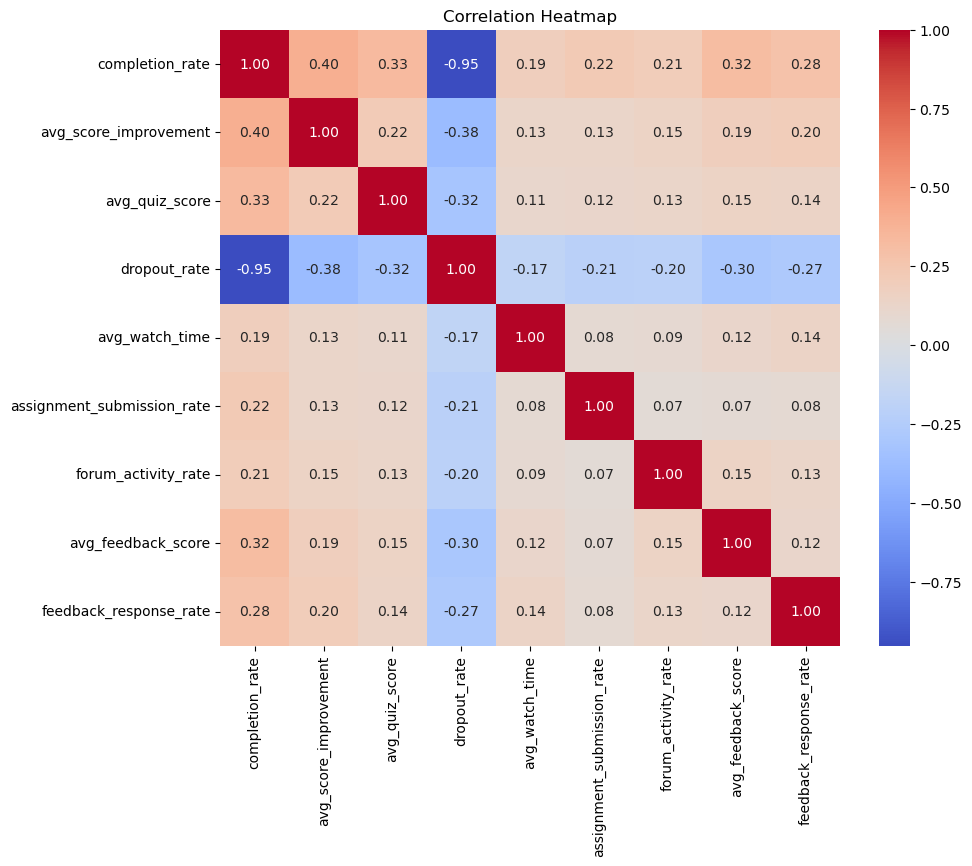

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Insights

- Completion rate has a positive relationship with assignment submission.
- Dropout rate is negatively related to completion rate.
- Higher watch time is associated with better quiz performance.

### Key Findings

- Completion rate and dropout rate have the strongest relationship (r = -0.95).
- Higher completion rates are associated with better quiz scores, greater score improvement, and higher feedback scores.
- Higher dropout rates are associated with poorer learning outcomes and lower student satisfaction.
- Average watch time, assignment submission, and forum activity show weak positive relationships with performance metrics, suggesting they may contribute but are not the primary drivers of instructor effectiveness.

### Relationship Analysis (Scatter Plots)

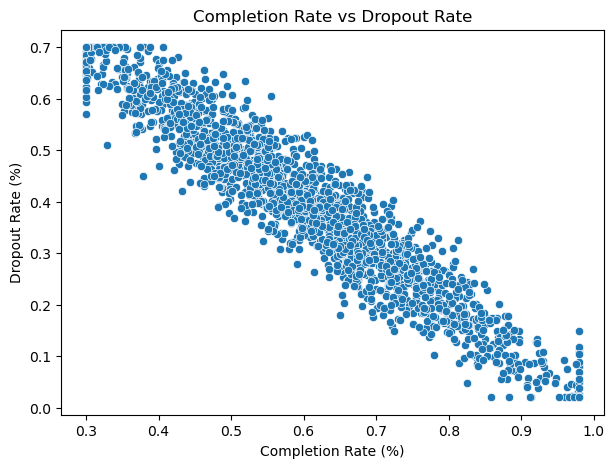

In [22]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='completion_rate',
    y='dropout_rate'
)

plt.title("Completion Rate vs Dropout Rate")
plt.xlabel("Completion Rate (%)")
plt.ylabel("Dropout Rate (%)")
plt.show()

### Observation
There is a strong negative relationship between completion rate and dropout rate. As the completion rate increases, the dropout rate decreases significantly.

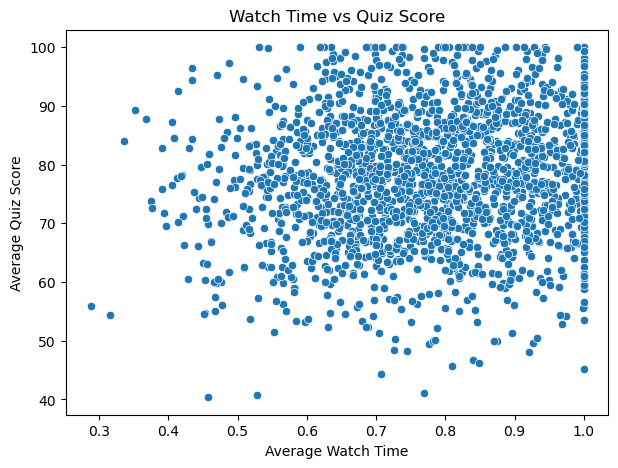

In [23]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='avg_watch_time',
    y='avg_quiz_score'
)

plt.title("Watch Time vs Quiz Score")
plt.xlabel("Average Watch Time")
plt.ylabel("Average Quiz Score")
plt.show()

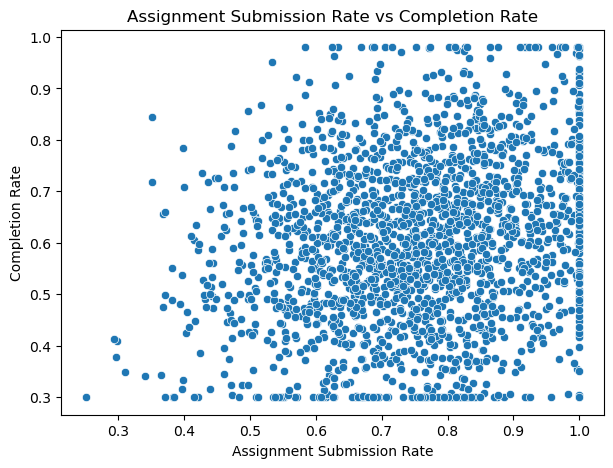

In [24]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='assignment_submission_rate',
    y='completion_rate'
)

plt.title("Assignment Submission Rate vs Completion Rate")
plt.xlabel("Assignment Submission Rate")
plt.ylabel("Completion Rate")
plt.show()

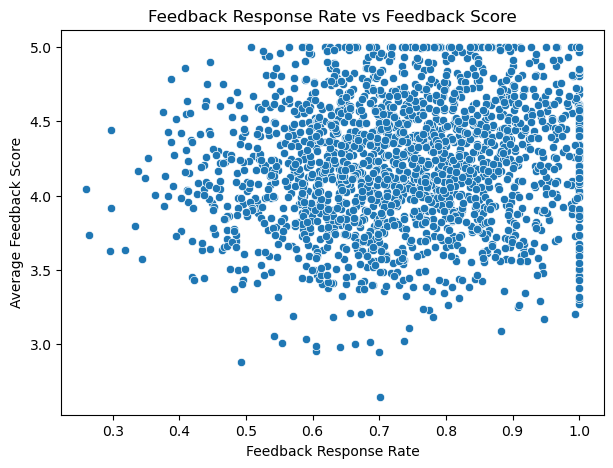

In [25]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='feedback_response_rate',
    y='avg_feedback_score'
)

plt.title("Feedback Response Rate vs Feedback Score")
plt.xlabel("Feedback Response Rate")
plt.ylabel("Average Feedback Score")
plt.show()

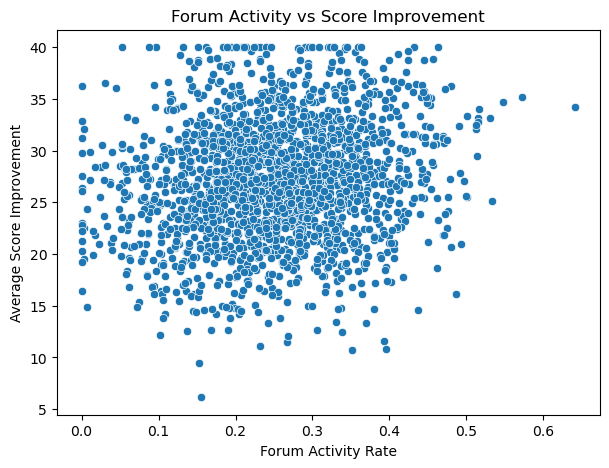

In [26]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='forum_activity_rate',
    y='avg_score_improvement'
)

plt.title("Forum Activity vs Score Improvement")
plt.xlabel("Forum Activity Rate")
plt.ylabel("Average Score Improvement")
plt.show()

### Top 10 Instructors by Completion Rate

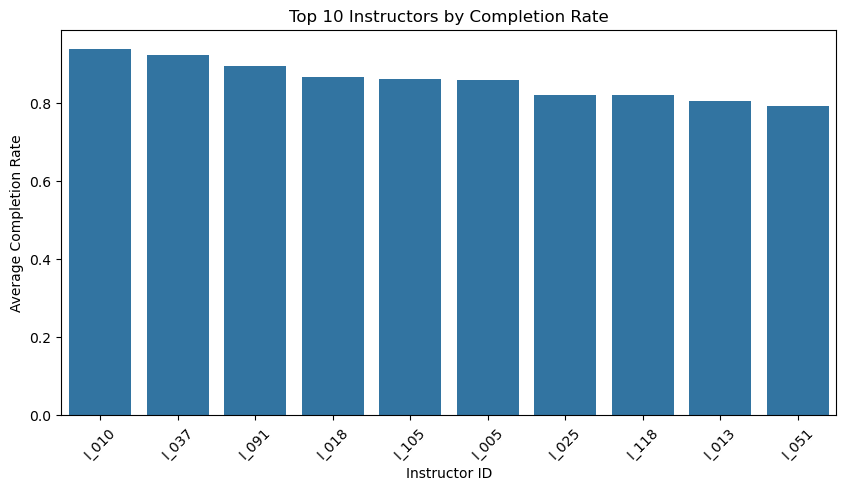

In [28]:
top_completion = (
    df.groupby('instructor_id')['completion_rate']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_completion.index, y=top_completion.values)

plt.title("Top 10 Instructors by Completion Rate")
plt.xlabel("Instructor ID")
plt.ylabel("Average Completion Rate")
plt.xticks(rotation=45)
plt.show()

In [30]:
#The chart identifies the top-performing instructors based on average completion rate.
#These instructors can be considered benchmarks for effective teaching practices.

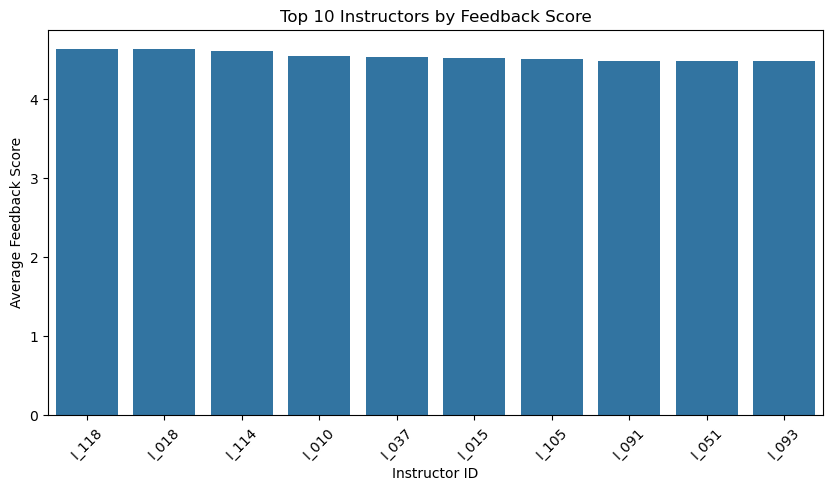

In [31]:
top_feedback = (
    df.groupby('instructor_id')['avg_feedback_score']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_feedback.index, y=top_feedback.values)

plt.title("Top 10 Instructors by Feedback Score")
plt.xlabel("Instructor ID")
plt.ylabel("Average Feedback Score")
plt.xticks(rotation=45)
plt.show()

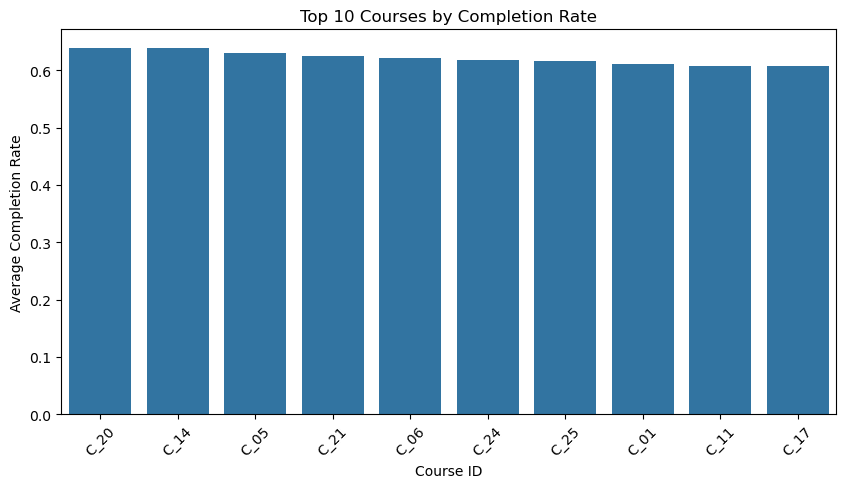

In [32]:
top_courses = (
    df.groupby('course_id')['completion_rate']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_courses.index, y=top_courses.values)

plt.title("Top 10 Courses by Completion Rate")
plt.xlabel("Course ID")
plt.ylabel("Average Completion Rate")
plt.xticks(rotation=45)
plt.show()

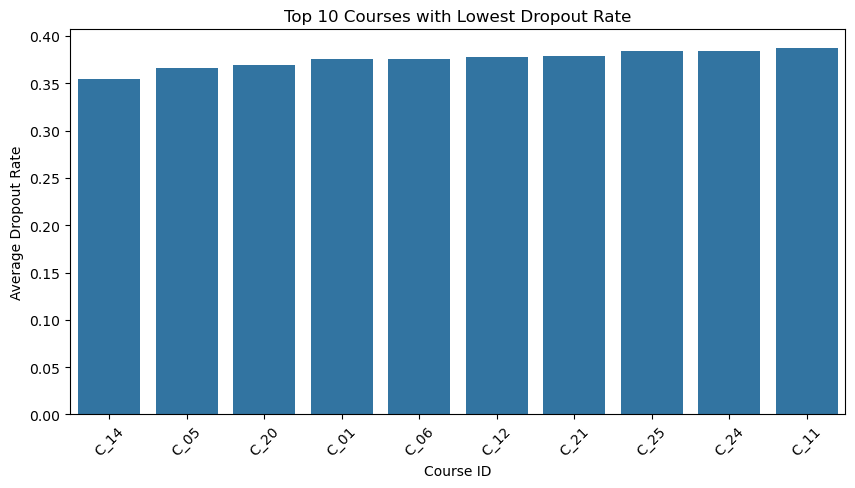

In [33]:
lowest_dropout = (
    df.groupby('course_id')['dropout_rate']
      .mean()
      .sort_values()
      .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=lowest_dropout.index, y=lowest_dropout.values)

plt.title("Top 10 Courses with Lowest Dropout Rate")
plt.xlabel("Course ID")
plt.ylabel("Average Dropout Rate")
plt.xticks(rotation=45)
plt.show()

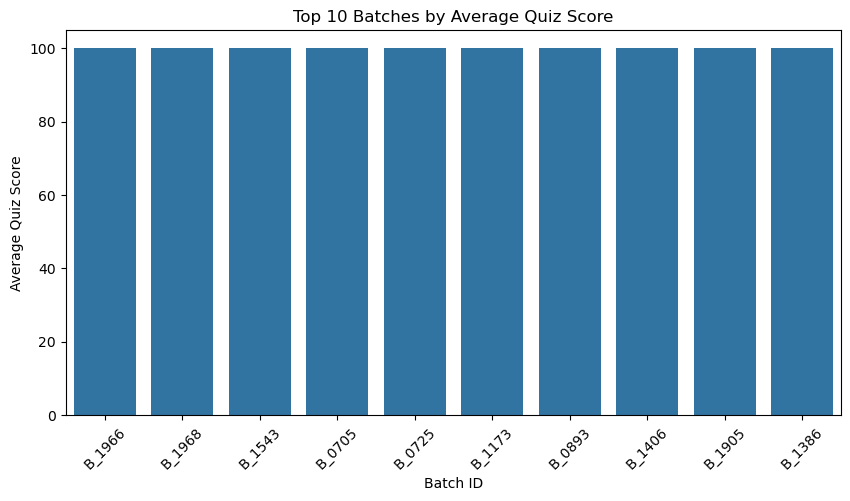

In [34]:
top_batches = (
    df.groupby('batch_id')['avg_quiz_score']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_batches.index, y=top_batches.values)

plt.title("Top 10 Batches by Average Quiz Score")
plt.xlabel("Batch ID")
plt.ylabel("Average Quiz Score")
plt.xticks(rotation=45)
plt.show()

# Key Business Insights
1. Completion rate and dropout rate have a very strong negative correlation (-0.95), indicating that improving course completion can significantly reduce student dropouts.

2. Students who complete courses tend to achieve higher quiz scores and greater score improvement.

3. Instructors with higher completion rates generally receive better student feedback scores.

4. Higher dropout rates are associated with lower academic performance and lower student satisfaction.

5. Average watch time has only a weak positive relationship with quiz scores, suggesting that simply watching more content does not guarantee better learning outcomes.

6. Assignment submission rate shows a positive relationship with course completion, highlighting the importance of continuous student engagement.

7. Forum activity has a weak positive association with score improvement, indicating that collaborative learning may contribute to student success.

8. Top-performing instructors consistently achieve high completion rates and feedback scores, making them suitable role models for teaching best practices.

# Recommendations
1. Encourage instructors to adopt teaching strategies used by the highest-performing instructors.

2. Monitor courses with high dropout rates and identify the causes of student disengagement.

3. Increase assignment participation through reminders and structured deadlines.

4. Promote discussion forum participation to improve student interaction and collaborative learning.

5. Encourage instructors to respond promptly to student feedback to enhance satisfaction.

6. Regularly monitor instructor performance using completion rate, feedback score, and quiz performance as key performance indicators (KPIs).

7. Use data-driven decision-making to identify underperforming courses and provide targeted support.

# Conclusion
This project analyzed instructor effectiveness using student engagement, academic performance, and feedback metrics. The analysis showed that completion rate is strongly associated with lower dropout rates and better student outcomes. Correlation analysis, visualizations, and group-wise comparisons helped identify key performance patterns among instructors, courses, and batches. The findings can support educational institutions in improving teaching quality, student engagement, and overall learning effectiveness through data-driven decisions.

# Future Scope
- Develop a machine learning model to predict instructor effectiveness.
- Build an interactive dashboard using Tableau or Power BI.
- Analyze instructor performance over multiple semesters.
- Incorporate additional student demographic and attendance data.
- Create automated performance reports for instructors and management.

# Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook